<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score
import seaborn as sns
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.utils import plot_model
import math
from tensorflow.keras.applications import VGG16
import time

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

import warnings

warnings.filterwarnings(
    "ignore",
    message="Do not pass an `input_shape`/`input_dim` argument",
    category=UserWarning
)

In [2]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
class_names=['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2067s 12us/step


In [3]:
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [4]:
X_train=X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

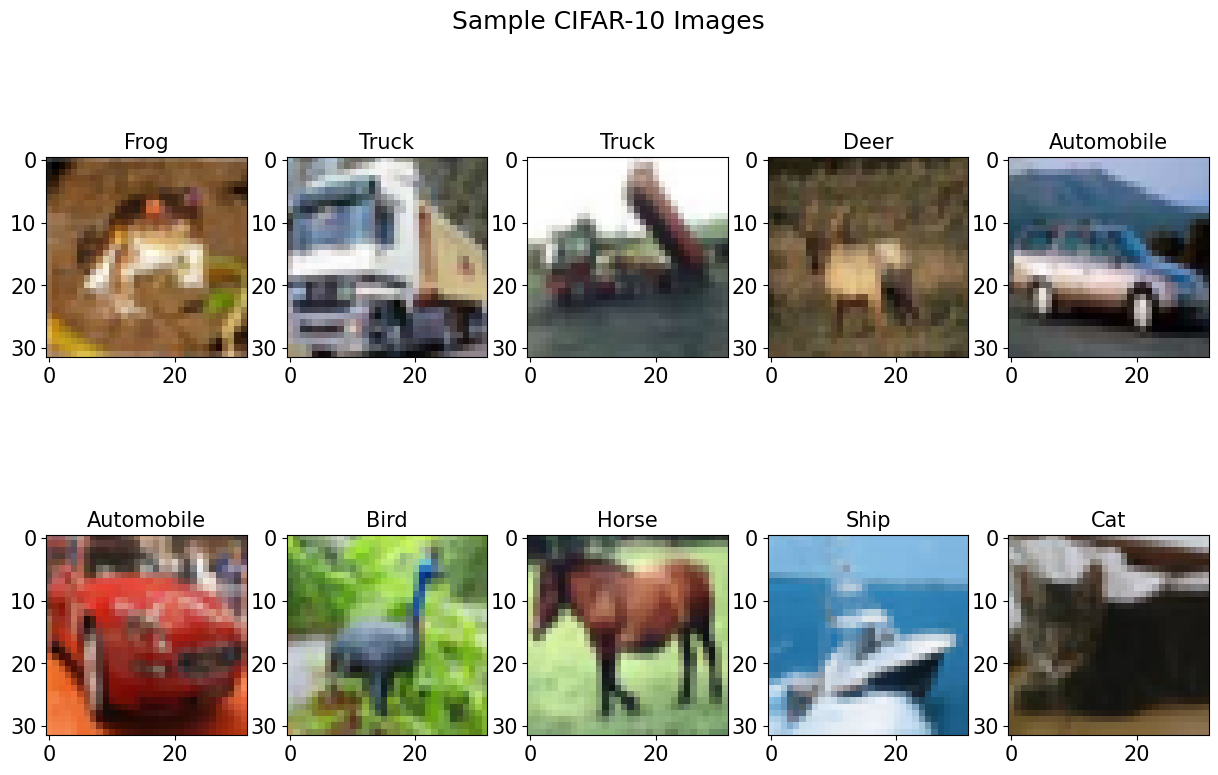

In [5]:
plt.figure(figsize=(15, 9))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])

plt.suptitle("Sample CIFAR-10 Images")
plt.savefig('sample_images.png',dpi=600)
plt.show()

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training labels after one-hot encoding:",y_train_cat.shape)

print("Testing labels after one-hot encoding:",y_test_cat.shape)

Training labels after one-hot encoding: (50000, 10)
Testing labels after one-hot encoding: (10000, 10)


In [7]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [8]:
from tensorflow.keras.layers import Resizing, GlobalAveragePooling2D

model=Sequential([
    Resizing(224, 224),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])

model.build(input_shape=(None, 32, 32, 3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
start_time = time.time()

In [11]:
history = model.fit(
    X_train,
    y_train_cat,
    batch_size=32,
    epochs=10,
    validation_split=0.1
)

training_time=time.time() -start_time

print("Training Time:",training_time,"seconds")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 274s 185ms/step - accuracy: 0.4678 - loss: 1.5155 - val_accuracy: 0.5334 - val_loss: 1.3051
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 183ms/step - accuracy: 0.5739 - loss: 1.2134 - val_accuracy: 0.6024 - val_loss: 1.1496
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 184ms/step - accuracy: 0.6067 - loss: 1.1240 - val_accuracy: 0.6160 - val_loss: 1.1003
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 183ms/step - accuracy: 0.6242 - loss: 1.0757 - val_accuracy: 0.6216 - val_loss: 1.0889
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 183ms/step - accuracy: 0.6330 - loss: 1.0421 - val_accuracy: 0.6516 - val_loss: 1.0126
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 183ms/step - accuracy: 0.6447 - loss: 1.0152 - val_accuracy: 0.6440 - val_loss: 1.0243
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 258s 183ms/step - accuracy: 0.6481 - loss: 0.9959 - val_accuracy: 0.6296 - val_loss: 1.0549
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 257s 183ms/step - ac

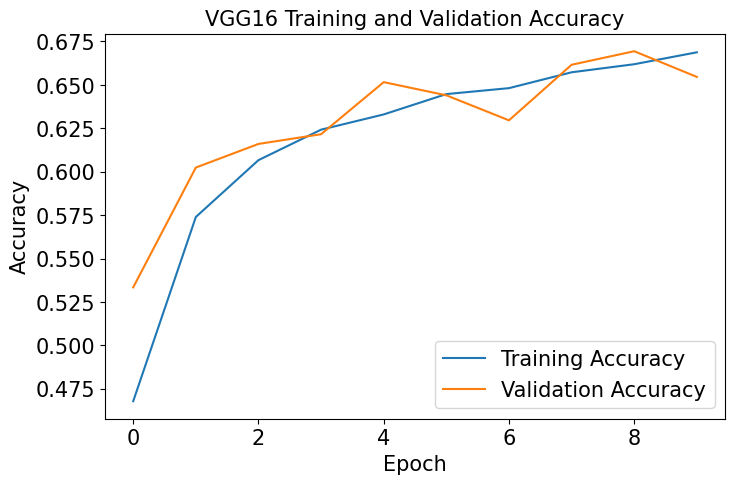

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig('vgg_accuracy.png',dpi=600)
plt.show()

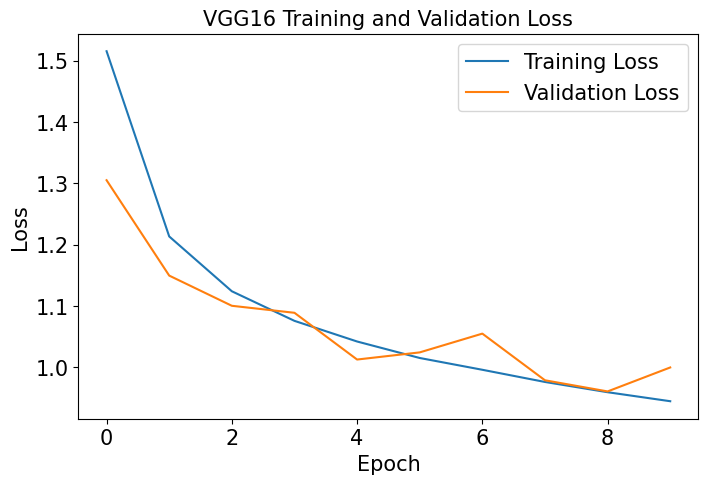

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig('vgg_loss.png',dpi=600)
plt.show()

In [14]:
base_model.trainable=True
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-4:]:
        layer.trainable = True

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
fine_start_time = time.time()

fine_history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    batch_size=32,
    epochs=5
)

fine_training_time = (time.time()-fine_start_time)

print("Fine-tuning Time:",round(fine_training_time, 2),"seconds")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 305s 213ms/step - accuracy: 0.7026 - loss: 0.8502 - val_accuracy: 0.7902 - val_loss: 0.5991
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 296s 210ms/step - accuracy: 0.8232 - loss: 0.5072 - val_accuracy: 0.8218 - val_loss: 0.5150
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 296s 210ms/step - accuracy: 0.8750 - loss: 0.3587 - val_accuracy: 0.8414 - val_loss: 0.4751
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 296s 211ms/step - accuracy: 0.9110 - loss: 0.2535 - val_accuracy: 0.8358 - val_loss: 0.5416
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 296s 211ms/step - accuracy: 0.9380 - loss: 0.1787 - val_accuracy: 0.8444 - val_loss: 0.5147
Fine-tuning Time: 1491.16 seconds


In [17]:
test_loss, test_accuracy=model.evaluate(X_test,y_test_cat,batch_size=32)

print("Test Accuracy:",test_accuracy*100,"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.8373 - loss: 0.5415
Test Accuracy: 83.73000025749207 %


In [18]:
y_pred_prob = model.predict(X_test,batch_size=32)
y_pred = np.argmax(y_pred_prob,axis=1)
y_true = y_test.flatten()
precision = precision_score(y_true,y_pred,average="weighted")
recall = recall_score(y_true,y_pred,average="weighted")
f1 = f1_score(y_true,y_pred,average="weighted")

print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 167ms/step
Precision: 0.8476940368798367
Recall   : 0.8373
F1-score : 0.8394134716265477


In [19]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.88      0.83      0.85      1000
  Automobile       0.87      0.95      0.91      1000
        Bird       0.77      0.81      0.79      1000
         Cat       0.62      0.82      0.71      1000
        Deer       0.83      0.84      0.84      1000
         Dog       0.82      0.72      0.77      1000
        Frog       0.95      0.78      0.86      1000
       Horse       0.87      0.88      0.88      1000
        Ship       0.93      0.89      0.91      1000
       Truck       0.94      0.85      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



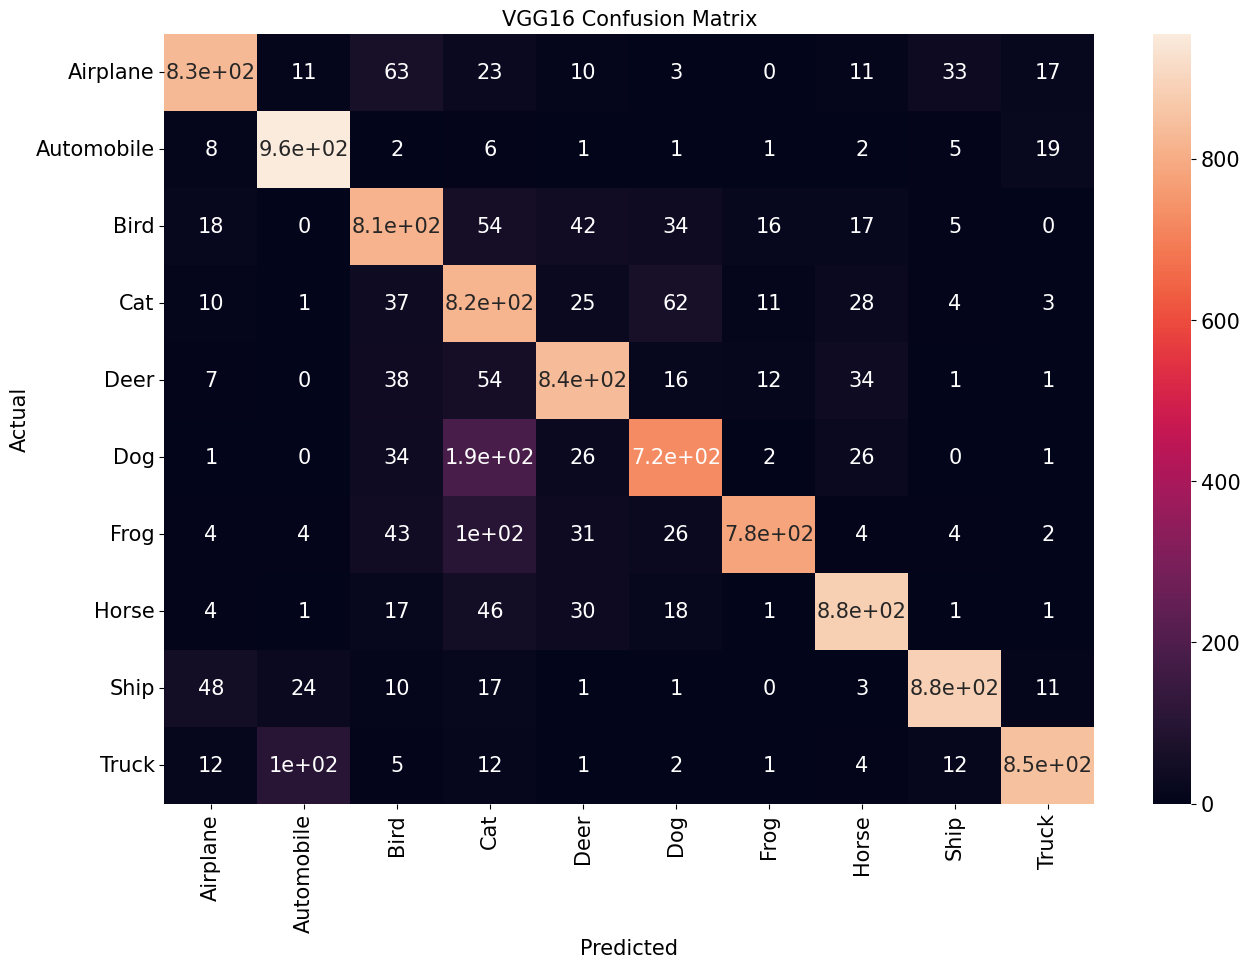

In [21]:
cm =confusion_matrix(y_true,y_pred)
plt.figure(figsize=(15, 10))
sns.heatmap(cm,annot=True,xticklabels=class_names,yticklabels=class_names)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('vgg_confusion_matrix.png',dpi=600)
plt.show()